In [ ]:
A Segment Tree is a binary tree-based data structure that is used to efficiently answer range queries and perform updates on an array. 
     It is especially useful when the dataset is changes dynamically.
	•	It divides an array into segments (intervals) and stores aggregated information (sum, minimum, maximum, GCD, etc.) for those segments.
	•	A segment tree takes O(N) space to store and can answer range queries in O(log N) time while allowing updates in O(log N) time.

Use Cases of Segment Trees

Segment trees are mainly used for:
1.	Range Queries (O(log N))
	•	Sum of elements in a given range.
	•	Minimum or maximum element in a given range.
	•	Greatest Common Divisor (GCD) in a given range.
	•	Count of elements satisfying a certain condition in a given range.
2.	Point Updates (O(log N))
	•	Updating a single element in the array.
	•	Applying operations like addition, subtraction, multiplication, or setting values at a position efficiently.
3.	Lazy Propagation (Efficient Range Updates)
	•	Used for efficiently handling range updates where multiple elements need to be updated.
	•	Example: Adding a value to all elements in a given range efficiently.

https://www.youtube.com/watch?v=NEG-SoyigGE 1:18

In [ ]:
1. Range Sum Queries (RSQ)
	•	Problem: Find the sum of elements in a given range [L, R].
	•	Use Case: Querying sum in dynamic arrays where elements can change.

2. Range Minimum / Maximum Query (RMQ)
	•	Problem: Find the minimum or maximum element in a given range [L, R].
	•	Use Case: Querying weather temperature over a period, stock price trends.

3. Range Greatest Common Divisor (GCD) Queries
	•	Problem: Find the GCD of all numbers in a given range [L, R].
	•	Use Case: Querying divisibility properties in number theory problems.

4. Range Updates with Lazy Propagation
	•	Problem: Add a value to all elements in a given range efficiently.
	•	Use Case: Simulating cumulative increases, bonus allocations in salaries.

5. K-th Order Statistics in a Subarray
	•	Problem: Find the k-th smallest or largest element in a given range [L, R].
	•	Use Case: Used in ranking systems, competitive programming.

6. Inversions Count in an Array
	•	Problem: Find how many times a larger number appears before a smaller number in an array.
	•	Use Case: Used in sorting algorithms, analyzing inversion complexity.

In [ ]:
class SegmentTree:
    def __init__(self, arr):
        self.n = len(arr)
        self.tree = [0] * (4 * self.n)
        self.build(arr, 0, 0, self.n - 1)

    def build(self, arr, node, start, end):
        if start == end:
            self.tree[node] = arr[start]
        else:
            mid = (start + end) // 2
            self.build(arr, 2 * node + 1, start, mid)
            self.build(arr, 2 * node + 2, mid + 1, end)
            self.tree[node] = self.tree[2 * node + 1] + self.tree[2 * node + 2]

    def query(self, node, start, end, L, R):
        if start > R or end < L:  # No overlap
            return 0
        if L <= start and end <= R:  # Total overlap
            return self.tree[node]
        # Partial overlap
        mid = (start + end) // 2
        left_sum = self.query(2 * node + 1, start, mid, L, R)
        right_sum = self.query(2 * node + 2, mid + 1, end, L, R)
        return left_sum + right_sum

    def update(self, node, start, end, idx, val):
        if start == end:
            self.tree[node] = val
        else:
            mid = (start + end) // 2
            if start <= idx <= mid:
                self.update(2 * node + 1, start, mid, idx, val)
            else:
                self.update(2 * node + 2, mid + 1, end, idx, val)
            self.tree[node] = self.tree[2 * node + 1] + self.tree[2 * node + 2]

# Example usage
arr = [1, 3, 5, 7, 9, 11]
st = SegmentTree(arr)
print(st.query(0, 0, len(arr) - 1, 1, 3))  # Sum from index 1 to 3
st.update(0, 0, len(arr) - 1, 1, 10)  # Update index 1 to value 10
print(st.query(0, 0, len(arr) - 1, 1, 3))  # Query again

In [ ]:
class SegmentTree:
    def __init__(self, arr):
        self.n = len(arr)
        self.tree = [0] * (4 * self.n)
        self.build(arr, 0, 0, self.n - 1)

    def build(self, arr, node, start, end):
        if start == end:
            self.tree[node] = arr[start]
        else:
            mid = (start + end) // 2
            self.build(arr, 2 * node + 1, start, mid)
            self.build(arr, 2 * node + 2, mid + 1, end)
            self.tree[node] = self.tree[2 * node + 1] + self.tree[2 * node + 2]

    def query(self, node, start, end, L, R):
        if start > R or end < L:  # No overlap
            return 0
        if L <= start and end <= R:  # Total overlap
            return self.tree[node]
        # Partial overlap
        mid = (start + end) // 2
        left_sum = self.query(2 * node + 1, start, mid, L, R)
        right_sum = self.query(2 * node + 2, mid + 1, end, L, R)
        return left_sum + right_sum

    def update(self, node, start, end, idx, val):
        if start == end:
            self.tree[node] = val
        else:
            mid = (start + end) // 2
            if start <= idx <= mid:
                self.update(2 * node + 1, start, mid, idx, val)
            else:
                self.update(2 * node + 2, mid + 1, end, idx, val)
            self.tree[node] = self.tree[2 * node + 1] + self.tree[2 * node + 2]

# Example usage
arr = [1, 3, 5, 7, 9, 11]
st = SegmentTree(arr)
print(st.query(0, 0, len(arr) - 1, 1, 3))  # Sum from index 1 to 3
st.update(0, 0, len(arr) - 1, 1, 10)  # Update index 1 to value 10
print(st.query(0, 0, len(arr) - 1, 1, 3))  # Query again

In [ ]:
- Each sub-array will be divided into almost 2 equal parts
- First half will go to the left side, and rest to second half.
- Tree Node Left Index: 2 * i + 1 and Tree Node Right Index: 2 * i + 2


class SegmentTree:
    def __init__(self, arr):
        self.n = len(arr)
        self.tree = [0] * (4 * self.n)
        self.build(arr, 0, 0, self.n - 1)

    def build(self, arr, index, start, end):
        """ TC: No. of nodes visited, O(N)
        """
        if start == end:
            self.tree[index] = arr[start]
        else:
            mid = (start + end) // 2
            self.build(arr, 2 * index + 1, start, mid)
            self.build(arr, 2 * index + 2, mid + 1, end)
            self.tree[index] = self.tree[2 * index + 1] + self.tree[2 * index + 2]

    def query(self, node, start, end, L, R):
        """
        - partial overlap: when the the current is part of requested range, with other few elements (like root node) return (left node + right node)
        - no overlap: when a node is out of requested range, return INT_MAX or default value
        - Complete overlap: when the current node range lies completely in the requrested range, return segment_tree[index)

        - we will go the node childrent, only when there is a partial overlap.
        TC: O(2 * log N) => log N
        """
        if start > R or end < L:  # No overlap
            return 0
        if L <= start and end <= R:  # Total overlap
            return self.tree[node]
        # Partial overlap
        mid = (start + end) // 2
        left_sum = self.query(2 * node + 1, start, mid, L, R)
        right_sum = self.query(2 * node + 2, mid + 1, end, L, R)
        return left_sum + right_sum

    def update(self, node, start, end, idx, val):
        """ TC: O(Log N)
        """
        if start == end:
            self.tree[node] = val
        else:
            mid = (start + end) // 2
            if start <= idx <= mid:
                self.update(2 * node + 1, start, mid, idx, val)
            else:
                self.update(2 * node + 2, mid + 1, end, idx, val)
            self.tree[node] = self.tree[2 * node + 1] + self.tree[2 * node + 2]

# Example usage
arr = [1, 3, 5, 7, 9, 11]
st = SegmentTree(arr)
print(st.query(0, 0, len(arr) - 1, 1, 3))  # Sum from index 1 to 3
st.update(0, 0, len(arr) - 1, 1, 10)  # Update index 1 to value 10
print(st.query(0, 0, len(arr) - 1, 1, 3))  # Query again

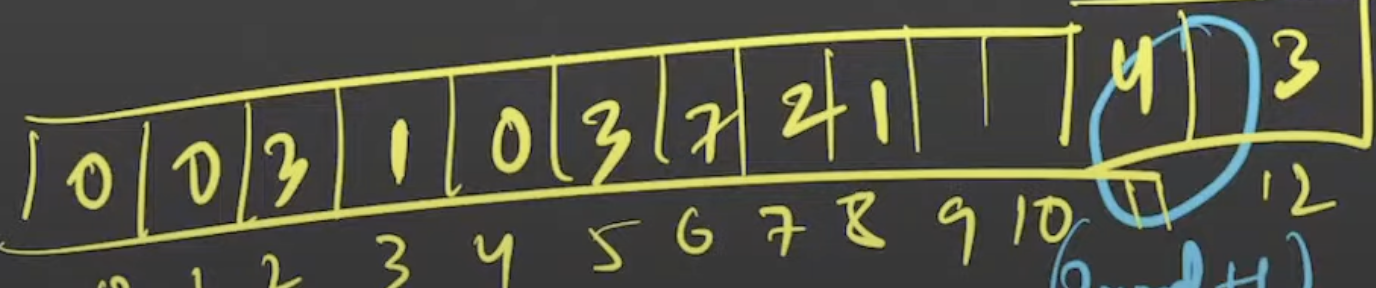

Min

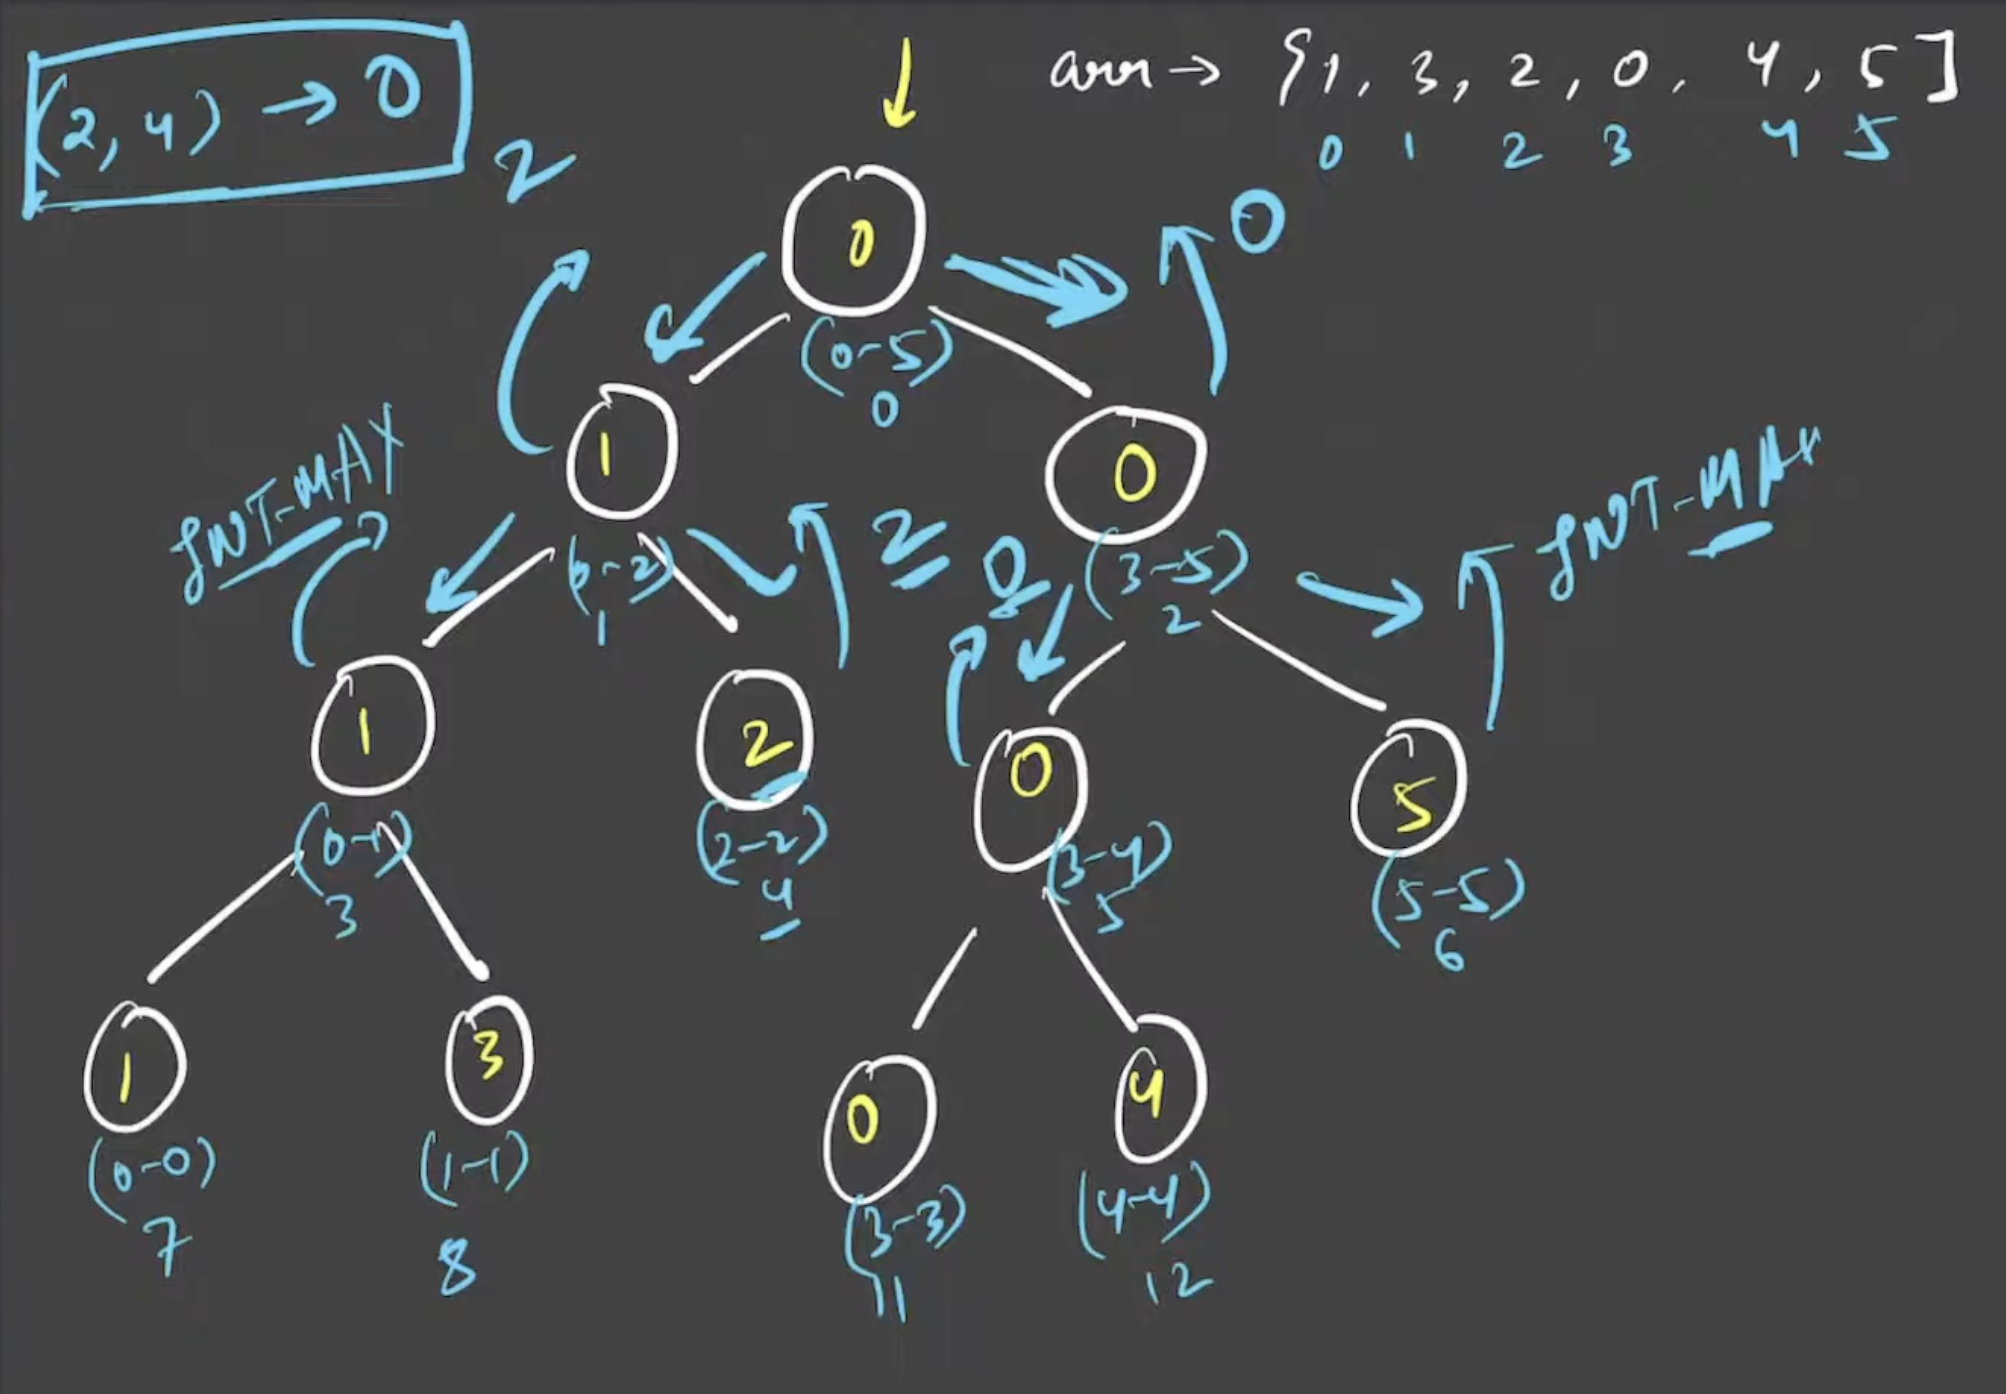